In [1]:
#Osnovne biblioteke

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from matplotlib.ticker import FuncFormatter
from collections import Counter
from scipy.stats import randint
from pathlib import Path
import joblib

In [2]:
#Scikit-learn – pipeline i transformacije

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    QuantileTransformer,
    FunctionTransformer,
    StandardScaler
)
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_selection import SelectFromModel, SelectKBest, f_regression, mutual_info_regression

In [3]:
#Scikit-learn – modeli

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    RidgeCV,
    Lasso,
    LassoCV,
    ElasticNet
)
from sklearn.ensemble import (
    RandomForestRegressor,
    StackingRegressor
)
from sklearn.neural_network import MLPRegressor

In [4]:
#Scikit-learn – evaluacija, metrika i 

from sklearn.model_selection import (
    train_test_split,
    cross_val_predict,
    KFold,
    GridSearchCV,
    RandomizedSearchCV,
    learning_curve
)
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_squared_log_error,
    make_scorer
)
from sklearn.inspection import permutation_importance

In [5]:
#Boosting modeli

import xgboost as xgb
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import category_encoders as ce

In [6]:
import warnings
warnings.filterwarnings("ignore")

In [7]:
current_directory = str(Path.cwd())
print(current_directory)

C:\Users\aleks\Sberbank\Sberbank-House-Pricing


In [8]:
data = pd.read_csv(current_directory+"/data_ceaned.csv")
df = pd.DataFrame(data)
pd.set_option('display.max_columns', 300)
pd.set_option('display.max_rows', 300)

In [9]:
df.head()

,full_sq,life_sq,floor,num_room,product_type,sub_area,area_m,raion_popul,green_zone_part,indust_part,children_preschool,preschool_quota,preschool_education_centers_raion,children_school,school_quota,school_education_centers_raion,school_education_centers_top_20_raion,healthcare_centers_raion,university_top_20_raion,sport_objects_raion,additional_education_raion,culture_objects_top_25,culture_objects_top_25_raion,shopping_centers_raion,office_raion,thermal_power_plant_raion,incineration_raion,oil_chemistry_raion,radiation_raion,railroad_terminal_raion,big_market_raion,nuclear_reactor_raion,detention_facility_raion,full_all,male_f,female_f,young_all,young_male,young_female,work_all,work_male,work_female,ekder_all,ekder_male,ekder_female,0_6_all,0_6_male,0_6_female,7_14_all,7_14_male,7_14_female,0_17_all,0_17_male,0_17_female,16_29_all,16_29_male,16_29_female,0_13_all,0_13_male,0_13_female,raion_build_count_with_material_info,build_count_block,build_count_wood,build_count_frame,build_count_brick,build_count_monolith,build_count_panel,build_count_foam,build_count_slag,build_count_mix,raion_build_count_with_builddate_info,build_count_before_1920,build_count_1921-1945,build_count_1946-1970,build_count_1971-1995,build_count_after_1995,ID_metro,metro_min_avto,metro_km_avto,metro_min_walk,metro_km_walk,kindergarten_km,school_km,park_km,green_zone_km,industrial_km,water_treatment_km,cemetery_km,incineration_km,railroad_station_walk_km,railroad_station_walk_min,ID_railroad_station_walk,railroad_station_avto_km,railroad_station_avto_min,ID_railroad_station_avto,public_transport_station_km,public_transport_station_min_walk,water_km,water_1line,mkad_km,ttk_km,sadovoe_km,bulvar_ring_km,kremlin_km,big_road1_km,ID_big_road1,big_road1_1line,big_road2_km,ID_big_road2,railroad_km,railroad_1line,zd_vokzaly_avto_km,ID_railroad_terminal,bus_terminal_avto_km,ID_bus_terminal,oil_chemistry_km,nuclear_reactor_km,radiation_km,power_transmission_line_km,thermal_power_plant_km,ts_km,big_market_km,market_shop_km,fitness_km,swim_pool_km,ice_rink_km,stadium_km,basketball_km,hospice_morgue_km,detention_facility_km,public_healthcare_km,university_km,workplaces_km,shopping_centers_km,office_km,additional_education_km,preschool_km,big_church_km,church_synagogue_km,mosque_km,theater_km,museum_km,exhibition_km,catering_km,ecology,green_part_500,prom_part_500,office_count_500,office_sqm_500,trc_count_500,trc_sqm_500,cafe_count_500,cafe_count_500_na_price,cafe_count_500_price_500,cafe_count_500_price_1000,cafe_count_500_price_1500,cafe_count_500_price_2500,cafe_count_500_price_4000,cafe_count_500_price_high,big_church_count_500,church_count_500,mosque_count_500,leisure_count_500,sport_count_500,market_count_500,green_part_1000,prom_part_1000,office_count_1000,office_sqm_1000,trc_count_1000,trc_sqm_1000,cafe_count_1000,cafe_sum_1000_min_price_avg,cafe_sum_1000_max_price_avg,cafe_avg_price_1000,cafe_count_1000_na_price,cafe_count_1000_price_500,cafe_count_1000_price_1000,cafe_count_1000_price_1500,cafe_count_1000_price_2500,cafe_count_1000_price_4000,cafe_count_1000_price_high,big_church_count_1000,church_count_1000,mosque_count_1000,leisure_count_1000,sport_count_1000,market_count_1000,green_part_1500,prom_part_1500,office_count_1500,office_sqm_1500,trc_count_1500,trc_sqm_1500,cafe_count_1500,cafe_sum_1500_min_price_avg,cafe_sum_1500_max_price_avg,cafe_avg_price_1500,cafe_count_1500_na_price,cafe_count_1500_price_500,cafe_count_1500_price_1000,cafe_count_1500_price_1500,cafe_count_1500_price_2500,cafe_count_1500_price_4000,cafe_count_1500_price_high,big_church_count_1500,church_count_1500,mosque_count_1500,leisure_count_1500,sport_count_1500,market_count_1500,green_part_2000,prom_part_2000,office_count_2000,office_sqm_2000,trc_count_2000,trc_sqm_2000,cafe_count_2000,cafe_sum_2000_min_price_avg,cafe_sum_2000_max_price_avg,cafe_avg_price_2000,cafe_count_2000_na_price,cafe_count_2000_price_500,cafe_count_2000_price_1000,cafe_count_2000_price_1500,cafe_count_2000_price_25

In [10]:
df.shape

(28906, 300)

In [11]:
df["sub_area_price_per_m2"] = df["sub_area"]

In [12]:
ordinal_cols = ["ecology"]
freq_cols = ["sub_area"]
nominal_cols = ['product_type', 'culture_objects_top_25', 'thermal_power_plant_raion',
                'incineration_raion', 'oil_chemistry_raion', 'radiation_raion', 
                'railroad_terminal_raion', 'big_market_raion', 'nuclear_reactor_raion', 
                'detention_facility_raion', 'water_1line', 'big_road1_1line', 'railroad_1line']
target_cols =["price_doc", "price_doc_log","price_per_m2","log_price_per_m2"]

In [13]:
df.loc[:, "ecology"] = df["ecology"].replace("no data", np.nan)

In [14]:
def bar_plot(df, col, y_label="price_doc"):
    plt.figure(figsize=(6,4))
    plt.hist(df[col].dropna(), bins=40, color="steelblue", edgecolor="black")
    plt.title(f"Distribucija {col}")
    plt.xlabel(col)
    plt.ylabel(y_label)
    plt.show()

def scatter_plot(df, col, target = "price_doc"):
    plt.figure(figsize=(6,4))
    plt.scatter(df[col], df[target], alpha=0.3)
    plt.title(f"{col} vs {target}")
    plt.xlabel(col)
    plt.ylabel(target)
    plt.show()

In [15]:
class FrequencyEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, columns=None, normalize=True):
        self.columns = columns
        self.normalize = normalize
        self.freq_maps = {}

    def fit(self, X, y=None):
        # Ako nije DataFrame, napravi ga
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X, columns=self.columns)

        for col in self.columns:
            self.freq_maps[col] = X[col].value_counts(normalize=self.normalize)
        return self

    def transform(self, X):
        # Ako nije DataFrame, napravi ga
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X, columns=self.columns)

        X = X.copy()
        for col in self.columns:
            X[col] = X[col].map(self.freq_maps[col]).fillna(0)
        return X
    def get_feature_names_out(self, input_features=None):
        return np.array(self.columns)

In [16]:
def create_preprocessor(nominal_cols, ordinal_cols, freq_cols, numeric_cols, sub_area_col="sub_area_price_per_m2"):
    transformers = [
        ("nominal", 
         Pipeline([
             ("imputer", SimpleImputer(strategy="most_frequent")),
             ("ohe", OneHotEncoder(drop="if_binary", handle_unknown="ignore", sparse_output=False))
         ]), 
         nominal_cols),
        
        ("ordinal", 
         Pipeline([
             ("imputer", SimpleImputer(strategy="most_frequent")),
             ("ord", OrdinalEncoder(categories=[["excellent", "good", "satisfactory", "poor"]]))
         ]), 
         ordinal_cols),
        
        ("freq", 
         Pipeline([
             ("imputer", SimpleImputer(strategy="most_frequent")),
             ("freq", FrequencyEncoder(columns=freq_cols))
         ]), 
         freq_cols),
        
        ("num", 
         Pipeline([
             ("imputer", SimpleImputer(strategy="median"))
         ]), 
         numeric_cols)
    ]


    transformers.append((
        "sub_area_enc",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("target_enc", ce.TargetEncoder())
        ]),
        [sub_area_col]
    ))

    preprocessor = ColumnTransformer(
        transformers=transformers,
        remainder="drop"
    )

    pipeline = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("quantile", QuantileTransformer(output_distribution="normal", random_state=42))
    ])
    
    return pipeline

In [17]:
def create_numeric_preprocessor(cols):

    numeric_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("quantile", QuantileTransformer(output_distribution="normal", random_state=42))
    ])
    
    num_preprocessor = ColumnTransformer([
        ("num", numeric_pipeline, cols)
    ])
    
    return num_preprocessor

In [18]:
def return_train_test(df_,  targets, target_col = "price_doc_log",):

    df_sorted = df_.copy()
    df_sorted["year_month"] = df_sorted["year"] * 100 + df_sorted["month"]

    df_sorted = df_sorted.sort_values("year_month")

    y = df_sorted[target_col]
    X = df_sorted.drop(columns=targets)
    
    split_idx = int(len(df_sorted) * 0.8)
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

    return X_train, X_test, y_train, y_test



In [19]:
def evaluate_regression(y_true, y_pred):
    y_pred_clip = np.maximum(0, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    rmsle = np.sqrt(mean_squared_log_error(y_true, y_pred_clip))

    print("MSE: ", mse)
    print("RMSE: ", rmse)
    print("MAE: ", mae)
    print("R²: ", r2)
    print("RMSLE: ", rmsle)

In [20]:
def unlog(y_log_pred):
    return np.expm1(y_log_pred)

In [21]:
X_train, X_test, y_train, y_test = return_train_test(df, target_cols)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (23124, 298)
X_test shape: (5782, 298)
y_train shape: (23124,)
y_test shape: (5782,)


In [22]:
X_train, X_test, y_train, y_test = return_train_test(df, target_cols)

num_cols = X_train.select_dtypes("number").columns.tolist()
numeric_preprocessor = create_preprocessor(nominal_cols, ordinal_cols, freq_cols, num_cols, sub_area_col="sub_area_price_per_m2")

In [23]:
df["sub_area_price_per_m2"].head()

0             Bibirevo
1    Nagatinskij Zaton
2       Tekstil'shhiki
3               Mitino
4            Basmannoe
Name: sub_area_price_per_m2, dtype: object

In [24]:
pipeline_lasso = Pipeline(steps=[
    ("preprocessor", numeric_preprocessor),
    ("model", LassoCV(cv=5))
])

pipeline_kbest = Pipeline(steps=[
    ("preprocessor", numeric_preprocessor),
    ("feature_selection", SelectKBest(score_func=f_regression, k=50)),  
    ("model", LinearRegression())
])

pipeline_mi = Pipeline(steps=[
    ("preprocessor", numeric_preprocessor),
    ("feature_selection", SelectKBest(score_func=mutual_info_regression, k=50)),  
    ("model", LinearRegression())
])

In [25]:
pipeline_lasso.fit(X_train, y_train)

coefs = pipeline_lasso.named_steps["model"].coef_

feature_names = pipeline_lasso.named_steps["preprocessor"].get_feature_names_out()

selected = [f for f, c in zip(feature_names, coefs) if c != 0]
print(f"Broj selektovanih kolona preko Lasa: {len(selected)}")

Broj selektovanih kolona preko Lasa: 123


In [26]:
y_pred_lasso = unlog(pipeline_lasso.predict(X_test))
y_test_unlog = unlog(y_test)

evaluate_regression(y_test_unlog, y_pred_lasso)

MSE:  7523255024633.096
RMSE:  2742855.2686266727
MAE:  1698246.2185996661
R²:  0.5888965621533617
RMSLE:  0.4426136563436597


In [27]:
pipeline_kbest.fit(X_train, y_train)
y_pred_kbest = unlog(pipeline_kbest.predict(X_test))
y_test_unlog = unlog(y_test)

evaluate_regression(y_test_unlog, y_pred_kbest)

MSE:  10644011195169.37
RMSE:  3262516.083511217
MAE:  2259717.019738122
R²:  0.4183648460028594
RMSLE:  0.4534014525808522


In [28]:
# pipeline_mi.fit(X_train, y_train)
# y_pred = unlog(pipeline_mi.predict(X_test))
# y_test_unlog = unlog(y_test)

# evaluate_regression(y_test_unlog, y_pred)

In [29]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV

xgb_pipeline = Pipeline(steps=[
    ("preprocessor", numeric_preprocessor),
    ("model", XGBRegressor(
        objective="reg:squarederror", 
        n_estimators=500, 
        random_state=42,
        tree_method="hist"  
    ))
])

In [30]:
param_dist = {
    "model__max_depth": [3, 5],
    "model__learning_rate": [0.05, 0.1],
    "model__subsample": [0.8],
    "model__colsample_bytree": [0.8],
    "model__n_estimators": [100, 200],
    "model__tree_method": ["hist"],
    "model__n_jobs": [1],
}

random_search = RandomizedSearchCV(
    xgb_pipeline,
    param_distributions=param_dist,
    n_iter=4,
    cv=2,
    scoring="neg_root_mean_squared_error",
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [31]:
random_search.fit(X_train, y_train)

print("Best params:", random_search.best_params_)

y_pred_xgb = unlog(random_search.predict(X_test))
y_test_unlog = unlog(y_test)
evaluate_regression(y_test_unlog, y_pred_xgb)

Fitting 2 folds for each of 4 candidates, totalling 8 fits
Best params: {'model__tree_method': 'hist', 'model__subsample': 0.8, 'model__n_jobs': 1, 'model__n_estimators': 200, 'model__max_depth': 3, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.8}
MSE:  7052499999642.565
RMSE:  2655654.3449106035
MAE:  1860473.8227689373
R²:  0.6146206680787256
RMSLE:  0.41915891957762386


In [32]:
best_pipeline = random_search.best_estimator_
xgb_model = best_pipeline.named_steps["model"]
feature_names = best_pipeline.named_steps["preprocessor"].get_feature_names_out()
importances = xgb_model.feature_importances_

In [33]:
feat_imp = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

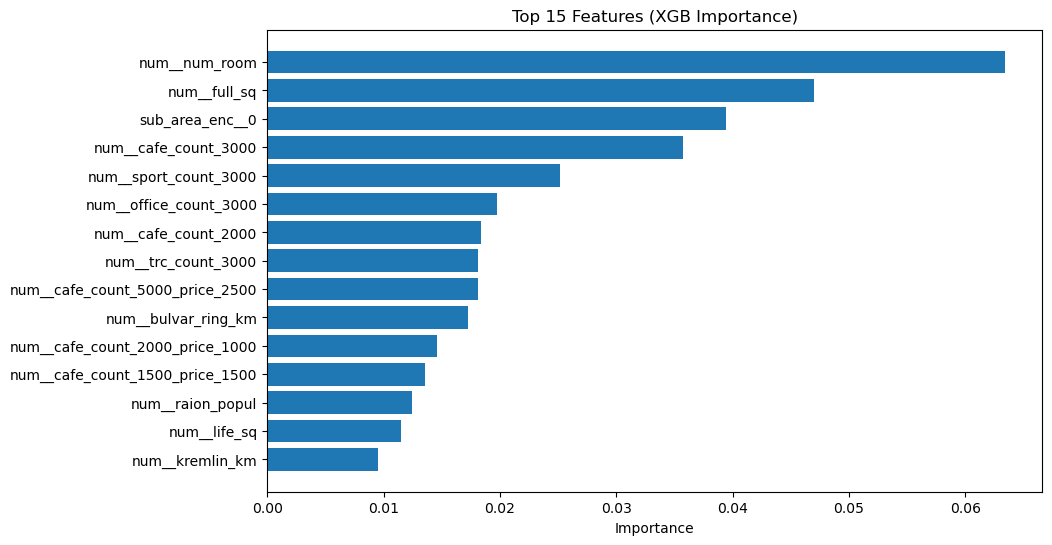

In [34]:
top15 = feat_imp.head(15)

plt.figure(figsize=(10,6))
plt.barh(top15["Feature"], top15["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 15 Features (XGB Importance)")
plt.xlabel("Importance")
plt.show()

In [35]:
best_pipeline = random_search.best_estimator_

joblib.dump(best_pipeline, "xgb_best_pipeline.pkl")

['xgb_best_pipeline.pkl']

In [36]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", numeric_preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

In [37]:
param_dist_rf = {
    "model__n_estimators": [5, 10],
    "model__max_depth": [5, 10],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

random_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=param_dist_rf,
    n_iter=2,
    cv=2,
    scoring="neg_root_mean_squared_error",
    verbose=1,
    random_state=42,
    n_jobs=-1
)

In [38]:
random_search.fit(X_train, y_train)

print("Best params:", random_search.best_params_)

y_pred_rf = unlog(random_search.predict(X_test))
y_test_unlog = unlog(y_test)
evaluate_regression(y_test_unlog, y_pred_rf)

Fitting 2 folds for each of 2 candidates, totalling 4 fits
Best params: {'model__n_estimators': 10, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_depth': 5}
MSE:  8924728590889.473
RMSE:  2987428.424396051
MAE:  2144492.3105053785
R²:  0.5123139394384973
RMSLE:  0.44015840572450765


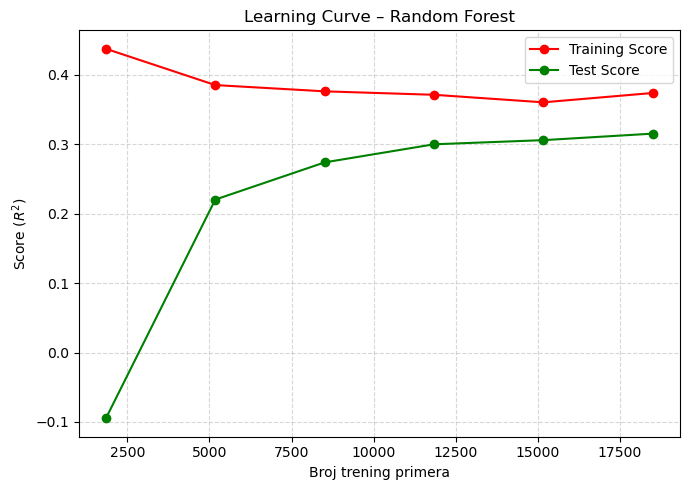

In [109]:
train_sizes, train_scores, test_scores = learning_curve(
    random_search.best_estimator_,
    X_train, y_train,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 6),
    random_state=42
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(7,5))
plt.plot(train_sizes, train_mean, "o-", color="red", label="Training Score")
plt.plot(train_sizes, test_mean, "o-", color="green", label="Test Score")
plt.title("Learning Curve – Random Forest")
plt.xlabel("Broj trening primera")
plt.ylabel("Score ($R^2$)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [39]:
from sklearn.ensemble import StackingRegressor, VotingRegressor

stack = StackingRegressor(
    estimators=[
        ("ridge", Ridge(alpha=1.0)),
        ("xgb", XGBRegressor(
            n_estimators=200,
            tree_method="hist",
            n_jobs=-1,
            objective="reg:squarederror",
            random_state=42
        )),
        ("lgbm", LGBMRegressor(
            n_estimators=300,
            learning_rate=0.05,
            num_leaves=31,
            n_jobs=-1,
            random_state=42
        ))
    ],
    final_estimator=LinearRegression(n_jobs=-1),
    n_jobs=-1
)

In [40]:
stack_pipeline = Pipeline(steps=[
    ("preprocessor", numeric_preprocessor),
    ("model", stack)
])

In [41]:
stack_pipeline.fit(X_train, y_train)

y_pred_stack = unlog(stack_pipeline.predict(X_test))
y_test_unlog = unlog(y_test)

evaluate_regression(y_test_unlog, y_pred_stack)

MSE:  5995859774265.886
RMSE:  2448644.4769026567
MAE:  1599511.1633603715
R²:  0.6723600944037802
RMSLE:  0.4100896311142867


In [42]:
stack_pipeline

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('preprocess', ...), ('quantile', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('nominal', ...), ('ordinal', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3


In [43]:
stack_model = stack_pipeline.named_steps["model"]
meta_model = stack_model.final_estimator_

base_names = [name for name, _ in stack_model.estimators]

weights = meta_model.coef_

df_weights = pd.DataFrame({
    "Model": base_names,
    "Težina": weights,
    "Apsolutno učešće (%)": 100 * abs(weights) / abs(weights).sum()
}).sort_values(by="Apsolutno učešće (%)", ascending=False)

print("\nUčešće baznih modela u Stacking Regressoru:\n")
print(df_weights.round(3))


Učešće baznih modela u Stacking Regressoru:

   Model  Težina  Apsolutno učešće (%)
2   lgbm   0.667                67.360
0  ridge   0.309                31.189
1    xgb   0.014                 1.451


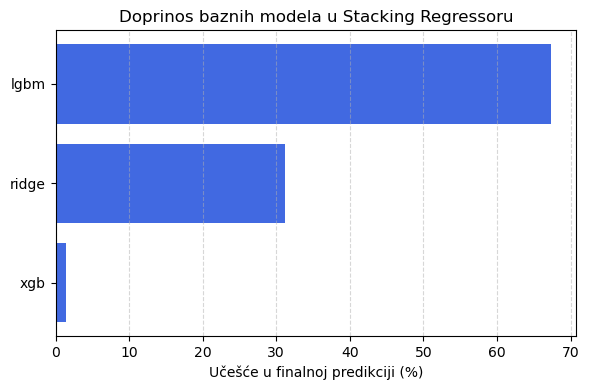

In [44]:
plt.figure(figsize=(6,4))
plt.barh(df_weights["Model"], df_weights["Apsolutno učešće (%)"], color="royalblue")
plt.gca().invert_yaxis()
plt.xlabel("Učešće u finalnoj predikciji (%)")
plt.title("Doprinos baznih modela u Stacking Regressoru")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

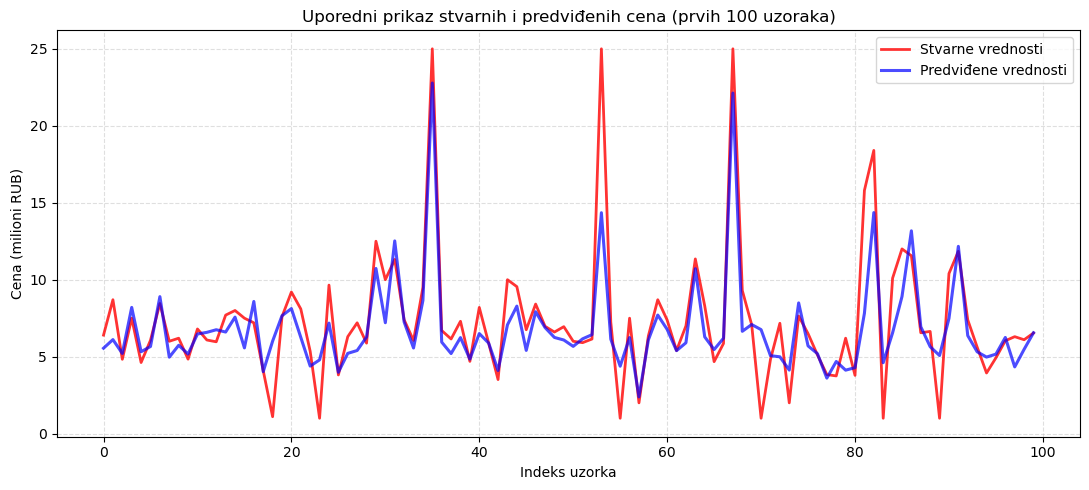

In [45]:
n = 100
y_true_sample = y_test_unlog[:n] / 1_000_000
y_pred_sample = y_pred_stack[:n] / 1_000_000

plt.figure(figsize=(11, 5))
plt.plot(y_true_sample.values, color="red", linewidth=2, label="Stvarne vrednosti", alpha=0.8)
plt.plot(y_pred_sample, color="blue", linewidth=2.2, label="Predviđene vrednosti", alpha=0.7)

plt.title("Uporedni prikaz stvarnih i predviđenih cena (prvih 100 uzoraka)")
plt.xlabel("Indeks uzorka")
plt.ylabel("Cena (milioni RUB)")
plt.legend(loc="upper right", frameon=True)
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

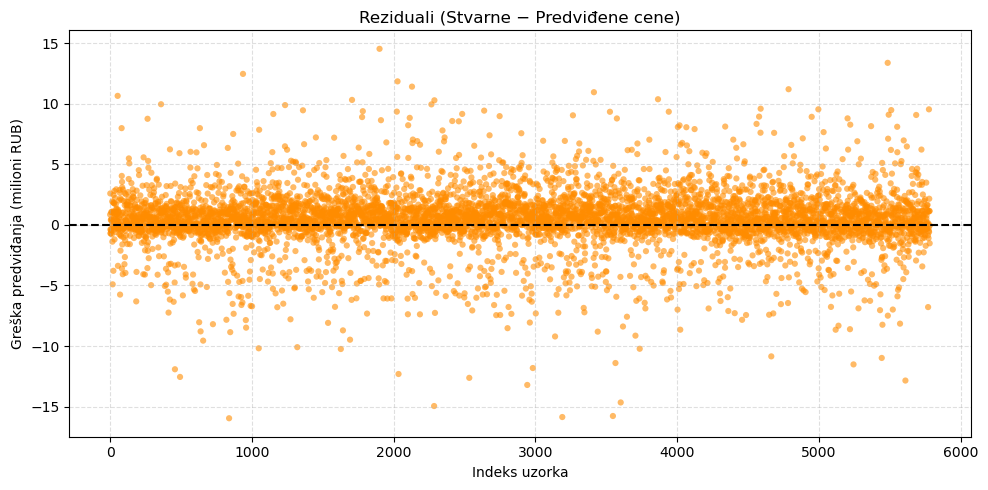

In [46]:
residuals = (y_test_unlog - y_pred_stack) / 1_000_000

plt.figure(figsize=(10,5))
plt.scatter(range(len(residuals)), residuals, 
            color="darkorange", alpha=0.6, s=20, edgecolors='none')

plt.axhline(0, color="black", linestyle="--", linewidth=1.5)
plt.title("Reziduali (Stvarne − Predviđene cene)")
plt.xlabel("Indeks uzorka")
plt.ylabel("Greška predviđanja (milioni RUB)")

plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

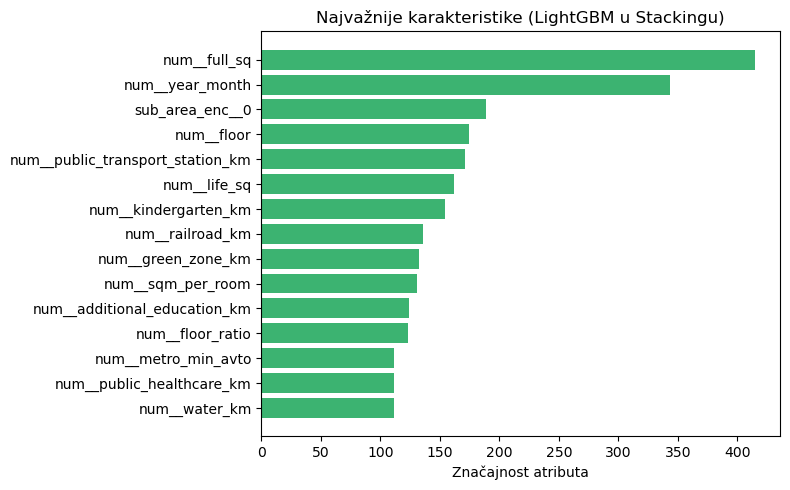

In [47]:
stack_model = stack_pipeline.named_steps["model"]
lgbm_model = dict(stack_model.named_estimators_)["lgbm"]  # uzima ga po imenu


features = stack_pipeline.named_steps["preprocessor"].get_feature_names_out()
importances = lgbm_model.feature_importances_

feat_imp = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values("Importance", ascending=False).head(15)


plt.figure(figsize=(8,5))
plt.barh(feat_imp["Feature"], feat_imp["Importance"], color="mediumseagreen")
plt.gca().invert_yaxis()
plt.title("Najvažnije karakteristike (LightGBM u Stackingu)")
plt.xlabel("Značajnost atributa")
plt.tight_layout()
plt.show()

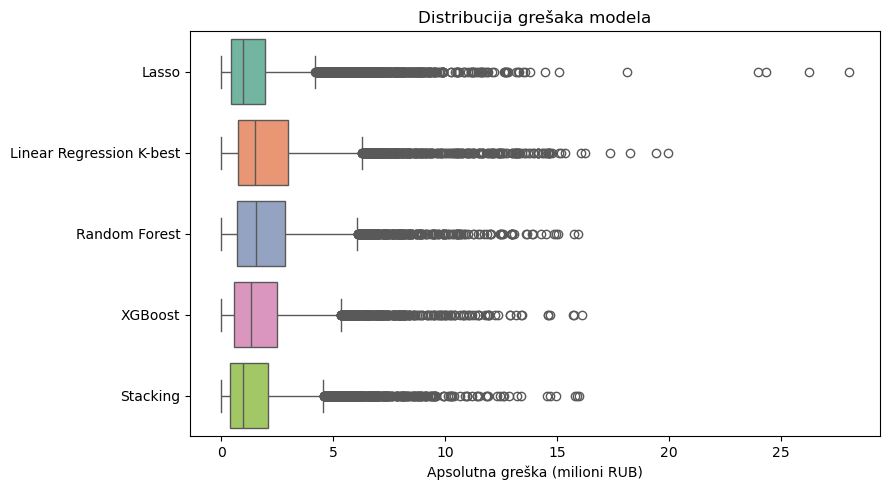

In [48]:
errors = {
    "Lasso": abs(unlog(y_test) - y_pred_lasso),
    "Linear Regression K-best": abs(unlog(y_test) - y_pred_kbest),
    "Random Forest": abs(unlog(y_test) - y_pred_rf),
    "XGBoost": abs(unlog(y_test) - y_pred_xgb),
    "Stacking": abs(unlog(y_test) - y_pred_stack)
}

rmsle_errors = {
    "Lasso": (np.log1p(y_pred_lasso) - np.log1p(unlog(y_test)))**2,
    "Linear Regression K-best": (np.log1p(y_pred_kbest) - np.log1p(unlog(y_test)))**2,
    "Random Forest": (np.log1p(y_pred_rf) - np.log1p(unlog(y_test)))**2,
    "XGBoost": (np.log1p(y_pred_xgb) - np.log1p(unlog(y_test)))**2,
    "Stacking": (np.log1p(y_pred_stack) - np.log1p(unlog(y_test)))**2,
}

df_errors = pd.DataFrame(errors)

df_errors = df_errors / 1_000_000

plt.figure(figsize=(9,5))
sns.boxplot(data=df_errors, orient="h", palette="Set2")
plt.xlabel("Apsolutna greška (milioni RUB)")
plt.title("Distribucija grešaka modela")
plt.tight_layout()
plt.show()

In [49]:
joblib.dump(stack_pipeline, "stack_pipeline.pkl")

['stack_pipeline.pkl']

In [50]:
df.to_csv("data_model.csv", index=False, encoding="utf-8")